In [2]:
import pandas as pd
import requests
from bs4 import  BeautifulSoup

In [10]:
response=requests.get("http://books.toscrape.com")
print(response.status_code)

200


In [11]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(response.text,'lxml')
print(soup.title.text,'lxml')
print(soup.title.text)



    All products | Books to Scrape - Sandbox
 lxml

    All products | Books to Scrape - Sandbox



In [12]:
# Find all books on the page
books = soup.find_all('article',class_='product_pod')
#How many books found?
print("Total books on this page:" ,len(books))
# see first book Html
print(books[0])

Total books on this page: 20
<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>


In [16]:
# 1 create a list of all books (they use the 'product_pod' class
books = soup.find_all('article',class_='product_pod')
#2 select the first  item in that list
first_book = books[0]
#3 .View the result
print(first_book)
print(len(books))


<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>
20


In [18]:
# look at first book only
first_book = books[0]
print(first_book)

<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>


In [19]:
# Get  title of first book
title = first_book.h3.a['title']
print("Title:",title)

Title: A Light in the Attic


In [20]:
# Get price of first book
price = first_book.find('p',class_='price_color').text
print("Price:",price)

Price: Â£51.77


In [21]:
# Get rating of first book
rating = first_book.find('p',class_='star-rating')['class'][1]
print("Rating:",rating)

Rating: Three


In [25]:
# Extract from first book
first_book = books[0]
title = first_book.h3.a['title']
price=first_book.find('p',class_='price_color').txt
rating=first_book.find('p',class_='star-rating')['class'][1]
print("Title:",title)
print("Price:",price)
print("Rating:",rating)

Title: A Light in the Attic
Price: None
Rating: Three


In [27]:
# lets exract data from ALL 20 books at once!
# Empty list to store all  books data
data = []
# Loop through every book
for book in books:
    # extract title
    title = book.h3.a['title']
    # Extract price
    price = book.find('p',class_='price_color').txt
    #Extract rating
    rating = book.find('p',class_= 'star-rating')['class'][1]
    #Add to list
    data.append({
        'title':title,
        'price':price,
        'rating':rating})
    # check how many books collected
    print("Total books collected:",len(data))
    # see first 3
    print(data[:3])
    

Total books collected: 1
[{'title': 'A Light in the Attic', 'price': None, 'rating': 'Three'}]
Total books collected: 2
[{'title': 'A Light in the Attic', 'price': None, 'rating': 'Three'}, {'title': 'Tipping the Velvet', 'price': None, 'rating': 'One'}]
Total books collected: 3
[{'title': 'A Light in the Attic', 'price': None, 'rating': 'Three'}, {'title': 'Tipping the Velvet', 'price': None, 'rating': 'One'}, {'title': 'Soumission', 'price': None, 'rating': 'One'}]
Total books collected: 4
[{'title': 'A Light in the Attic', 'price': None, 'rating': 'Three'}, {'title': 'Tipping the Velvet', 'price': None, 'rating': 'One'}, {'title': 'Soumission', 'price': None, 'rating': 'One'}]
Total books collected: 5
[{'title': 'A Light in the Attic', 'price': None, 'rating': 'Three'}, {'title': 'Tipping the Velvet', 'price': None, 'rating': 'One'}, {'title': 'Soumission', 'price': None, 'rating': 'One'}]
Total books collected: 6
[{'title': 'A Light in the Attic', 'price': None, 'rating': 'Three'},

In [28]:
import pandas as pd
# convert list to DataFrame
df = pd.DataFrame(data)
# see the data
print(df.head())

                                   title price rating
0                   A Light in the Attic  None  Three
1                     Tipping the Velvet  None    One
2                             Soumission  None    One
3                          Sharp Objects  None   Four
4  Sapiens: A Brief History of Humankind  None   Five


In [34]:
import time

# Empty list for all pages data
all_data = []

# Loop through 5 pages
for page in range(1, 6):
    
    # Build URL for each page
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
    print(f"Scraping page {page}...")
    
    # Get page
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'lxml')
    
    # Get all books
    books = soup.find_all('article', class_='product_pod')
    
    # Extract each book
    for book in books:
        title = book.h3.a['title']
        price = book.find('p', class_='price_color').text
        rating = book.find('p', class_='star-rating')['class'][1]
        
        all_data.append({
            'title': title,
            'price': price,
            'rating': rating,
            'page': page
        })
    
    # Wait 1 second — be polite to website!
    time.sleep(1)

print(f"Total books scraped: {len(all_data)}")

Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Total books scraped: 100


In [35]:
# convert to DataFrame
df = pd.DataFrame(all_data)
# see the data
print(df.head(10))
print(df.shape)

                                               title    price rating  page
0                               A Light in the Attic  Â£51.77  Three     1
1                                 Tipping the Velvet  Â£53.74    One     1
2                                         Soumission  Â£50.10    One     1
3                                      Sharp Objects  Â£47.82   Four     1
4              Sapiens: A Brief History of Humankind  Â£54.23   Five     1
5                                    The Requiem Red  Â£22.65    One     1
6  The Dirty Little Secrets of Getting Your Dream...  Â£33.34   Four     1
7  The Coming Woman: A Novel Based on the Life of...  Â£17.93  Three     1
8  The Boys in the Boat: Nine Americans and Their...  Â£22.60   Four     1
9                                    The Black Maria  Â£52.15    One     1
(100, 4)


In [36]:
# save to  csv file
df.to_csv('books_data.csv',index = False)
print("Saved sucessfully!")

Saved sucessfully!


In [37]:
# Clean price column — remove £ sign
df['price_clean'] = df['price'].str.replace('£', '').astype(float)

# Average price
print("Average price:", df['price_clean'].mean())

# Most common rating
print("\nRating counts:")
print(df['rating'].value_counts())

# Highest priced book
print("\nMost expensive book:")
print(df.loc[df['price_clean'].idxmax()])

ValueError: could not convert string to float: 'Â51.77'

SyntaxError: invalid character '←' (U+2190) (1023947005.py, line 21)

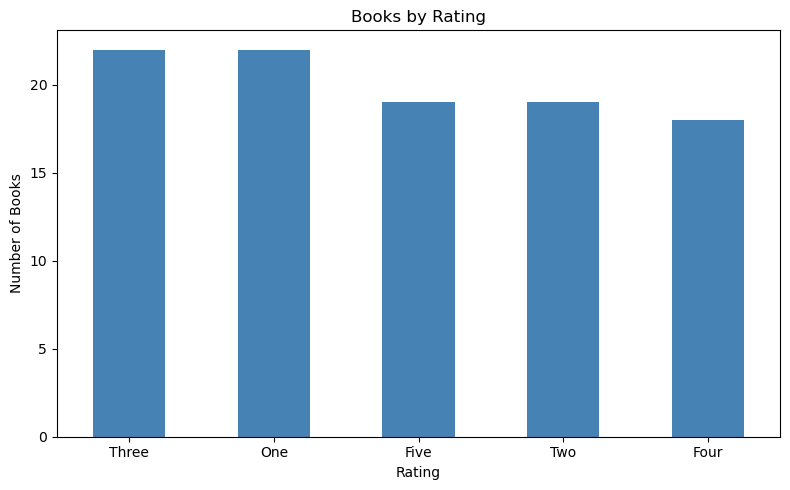

In [39]:
import matplotlib.pyplot as plt

# Plot rating distribution
df['rating'].value_counts().plot(
    kind='bar',
    color='steelblue',
    figsize=(8, 5)
)
plt.title('Books by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Books')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()